# 教程：退相干分析

这个 notebook 展示两类常用估算：

- **能量弛豫 / T1**：控制线通过电容或电感耦合到 qubit 后，理想 50 Ohm 线带来的损耗。
- **纯退相位 / Tphi**：Z 线 current noise 经过电子学链路后，通过 flux sensitivity 转换成 qubit 频率噪声。

所有数据都是公开安全的合成数据；代码块里的参数可以直接替换成自己的器件参数。

## 结构

1. 导入依赖和公开 API。
2. 在 `drive_loss(...)` 调用前直接填写接地/浮地 transmon 和控制线参数。
3. 在 `ElectronicNoise(...)` 调用前直接填写 PSD、温度链和衰减链参数。
4. 在 `ZNoiseDecoherence(...)` 调用前直接填写退相位模型参数。
5. 做几个小改动，检查 T1/Tphi 对参数的响应。

In [4]:
from __future__ import annotations

import importlib.util
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

required = ["numpy", "matplotlib", "qutip"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    raise ModuleNotFoundError(
        "Install the runtime dependencies first: " + ", ".join(missing)
    )

from pysuqu.decoherence import ElectronicNoise, ZNoiseDecoherence
from pysuqu.qubit import FloatingTransmon, GroundedTransmon


def configure_matplotlib_chinese():
    preferred_fonts = [
        "Microsoft YaHei",
        "SimHei",
        "SimSun",
        "DengXian",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "WenQuanYi Zen Hei",
        "PingFang SC",
        "Arial Unicode MS",
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    selected_font = next((name for name in preferred_fonts if name in available_fonts), None)
    if selected_font is not None:
        current_fonts = list(plt.rcParams.get("font.sans-serif", []))
        plt.rcParams["font.sans-serif"] = [selected_font] + current_fonts
    plt.rcParams["axes.unicode_minus"] = False
    return selected_font or "未找到常见中文字体"


CHINESE_FONT = configure_matplotlib_chinese()
CHINESE_FONT


'Microsoft YaHei'

## 第一部分：控制线导致的能量弛豫 `T1`

下面这个 cell 里，参数就写在构造 qubit 和调用 `drive_loss(...)` 前面。把 `grounded_params`、`floating_params`、`capa_drive`、`indu_drive` 改成自己的值即可。把某个耦合设为 `0` 或 `None`，就会关闭对应损耗通道。

In [ ]:
def quiet_construct(constructor, **kwargs):
    with redirect_stdout(StringIO()):
        return constructor(**kwargs)


def drive_loss_summary(label, qubit, *, capa_drive, indu_drive):
    with redirect_stdout(StringIO()):
        freq_ghz, t1_ind_s, t1_cap_s, t1_total_s = qubit.drive_loss(
            capa_drive=capa_drive,
            indu_drive=indu_drive,
        )
    return {
        "qubit": label,
        "f01_GHz": float(freq_ghz),
        "T1_inductive_us": float(t1_ind_s * 1e6),
        "T1_capacitive_us": float(t1_cap_s * 1e6),
        "T1_drive_total_us": float(t1_total_s * 1e6),
    }


# 用户替换区：接地 transmon 参数。
grounded_params = {
    "capacitance": 80e-15,
    "junction_resistance": 10_000.0,
    "inductance": 1e20,
    "flux": 0.0,
    "trunc_ener_level": 6,
    "junc_ratio": 1.0,
    "qr_couple": [3e-15],
}

# 用户替换区：浮地 transmon 参数。basic_element = [C1, C2, C_sigma, junction_resistance]。
floating_params = {
    "basic_element": [70e-15, 85e-15, 4e-15, 10_000.0],
    "flux": 0.0,
    "trunc_ener_level": 6,
    "junc_ratio": 1.0,
    "qr_couple": [4e-15, 0.0],
}

# 用户替换区：控制线耦合。SI 单位；设为 None 或 0 可关闭该通道。
capa_drive = 0.35e-15
indu_drive = 0.80e-12

grounded_qubit = quiet_construct(GroundedTransmon, **grounded_params)
floating_qubit = quiet_construct(FloatingTransmon, **floating_params)

loss_rows = [
    drive_loss_summary("接地 transmon", grounded_qubit, capa_drive=capa_drive, indu_drive=indu_drive),
    drive_loss_summary("浮地 transmon", floating_qubit, capa_drive=capa_drive, indu_drive=indu_drive),
]
loss_rows


[{'qubit': '接地 transmon',
  'f01_GHz': 5.216759904278737,
  'T1_inductive_us': 541.4484900371352,
  'T1_capacitive_us': inf,
  'T1_drive_total_us': 541.4484900371352},
 {'qubit': '浮地 transmon',
  'f01_GHz': 5.097326596923444,
  'T1_inductive_us': 565.7198298900602,
  'T1_capacitive_us': inf,
  'T1_drive_total_us': 565.7198298900602}]

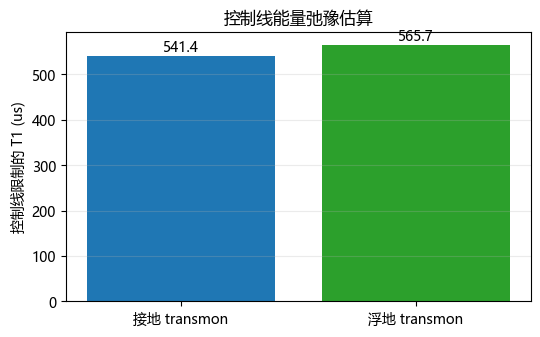

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5))
labels = [row["qubit"] for row in loss_rows]
total_t1_us = [row["T1_drive_total_us"] for row in loss_rows]
ax.bar(labels, total_t1_us, color=["tab:blue", "tab:green"])
ax.set_ylabel("控制线限制的 T1 (us)")
ax.set_title("控制线能量弛豫估算")
ax.grid(alpha=0.25, axis="y")
for idx, value in enumerate(total_t1_us):
    ax.text(idx, value, f"{value:.1f}", ha="center", va="bottom")
plt.show()


## 第二部分：电子学噪声链路

这个 cell 直接在 `ElectronicNoise(...)` 前填写 PSD 文件、温度链和衰减链。demo 自带的 CSV 是紧凑合成 PSD 窗口，适合演示噪声链路和白噪声温度诊断。

In [ ]:
repo_root = Path.cwd()
if repo_root.name == "demo":
    repo_root = repo_root.parent

# 用户替换区：可以换成自己的 PSD 文件；列名需对应下面读取的字段。
window_data_path = repo_root / "demo" / "data" / "synthetic_flux_noise_psd.csv"
psd_table = np.genfromtxt(window_data_path, delimiter=",", names=True)
window_freq = psd_table["frequency_hz"]
window_psd_single = psd_table["psd_single_a2_per_hz"]

# 用户替换区：从室温端到芯片端的温度链和衰减链。
temperature_setup = np.array([290, 45, 3.5, 0.9, 0.1, 0.01])
attenuation_setup = np.array([40, 1, 10, 10, 20, 10])

noise = ElectronicNoise(
    psd_freq=window_freq,
    psd_S=window_psd_single,
    noise_type="1f",
    noise_prop="single",
    is_spectral=True,
    T_setup=temperature_setup,
    attenuation_setup=attenuation_setup,
    is_print=False,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(window_freq, window_psd_single, marker="o")
ax.set_xlabel("频率 (Hz)")
ax.set_ylabel("单边 PSD (A^2/Hz)")
ax.set_title("紧凑合成 PSD 窗口")
ax.grid(alpha=0.3, which="both")
plt.show()

{
    "window_freq_range_hz": [float(window_freq[0]), float(window_freq[-1])],
    "input_white_noise_a2_per_hz": float(noise.input_stage.white_noise),
    "output_white_noise_a2_per_hz": float(noise.output_stage.white_noise),
    "input_white_noise_temperature_k": float(noise.input_stage.white_noise_temperature),
    "output_white_noise_temperature_k": float(noise.output_stage.white_noise_temperature),
    "corner_frequency_hz": float(noise.output_stage.fit_result.fit_diagnostics["corner_freq"]),
}


## 第三部分：由 flux noise 导致的纯退相位

这一部分的参数紧贴 `ZNoiseDecoherence(...)` 调用。`z_mutual_inductance` 是 Z/noise 线到 qubit loop 的互感；`idle_detuning_ghz` 用来选择计算 sensitivity 的 idle 频点。

In [ ]:
# 用户替换区：宽频 PSD 和 qubit / Z 线参数。
# demo 默认使用较少采样点以便快速运行；需要更平滑曲线时可调大点数。
dephasing_freq = np.logspace(np.log10(2e4), 8, 400)
one_over_f_coef = 5e-16
white_floor_a2_per_hz = 4e-21
dephasing_psd_single = one_over_f_coef / dephasing_freq + white_floor_a2_per_hz

qubit_freq_hz = 5e9
qubit_anharm_hz = -250e6
z_mutual_inductance = 1.5e-12
idle_detuning_ghz = 0.10

# 用户替换区：退相位计算使用的温度链和衰减链。通常可以和上一部分保持一致。
dephasing_temperature_setup = temperature_setup
dephasing_attenuation_setup = attenuation_setup

with redirect_stdout(StringIO()):
    z_noise = ZNoiseDecoherence(
        psd_freq=dephasing_freq,
        psd_S=dephasing_psd_single,
        noise_type="1f",
        noise_prop="single",
        qubit_freq=qubit_freq_hz,
        qubit_anharm=qubit_anharm_hz,
        couple_term=z_mutual_inductance,
        T_setup=dephasing_temperature_setup,
        attenuation_setup=dephasing_attenuation_setup,
        is_print=False,
    )

idle_freq = z_noise.qubit_freq - idle_detuning_ghz * 1e9
sensitivity = z_noise.get_sensitivity_at_idle(idle_freq=idle_freq)
sensitivity_factor = sensitivity * z_noise.couple_term

noise_freq_for_dephasing = z_noise.noise.output_stage.frequency
psd_for_dephasing = z_noise.noise.output_stage.psd_single

delay_list = np.linspace(0.05, 50.0, 40) * 1e-6
ramsey_prob = z_noise.cal_dephase(
    psd=psd_for_dephasing,
    noise_freq=noise_freq_for_dephasing,
    sensitivity_factor=sensitivity_factor,
    experiment="Ramsey",
    delay_list=delay_list,
)
echo_prob = z_noise.cal_dephase(
    psd=psd_for_dephasing,
    noise_freq=noise_freq_for_dephasing,
    sensitivity_factor=sensitivity_factor,
    experiment="SpinEcho",
    delay_list=delay_list,
)

tphi1_s = z_noise.cal_tphi1(idle_freq=idle_freq, is_print=False)
tphi2_result = z_noise.cal_tphi2(
    method="cal",
    experiment="Ramsey",
    delay_list=delay_list,
    idle_freq=idle_freq,
    is_print=False,
    is_plot=False,
)

fig, (ax_psd, ax_env) = plt.subplots(1, 2, figsize=(11, 4))
ax_psd.loglog(noise_freq_for_dephasing, psd_for_dephasing, color="tab:purple")
ax_psd.set_xlabel("频率 (Hz)")
ax_psd.set_ylabel("输出端 PSD (A^2/Hz)")
ax_psd.set_title("链路后的宽频合成 PSD")
ax_psd.grid(alpha=0.3, which="both")

ax_env.plot(delay_list * 1e6, ramsey_prob, label="Ramsey", linewidth=2)
ax_env.plot(delay_list * 1e6, echo_prob, label="Spin Echo", linewidth=2)
ax_env.set_xlabel("延迟时间 (us)")
ax_env.set_ylabel("相干包络")
ax_env.set_title("纯退相位包络")
ax_env.grid(alpha=0.3)
ax_env.legend()

plt.tight_layout()
plt.show()

{
    "idle_freq_ghz": float(idle_freq / 1e9),
    "sensitivity_rad_per_s_per_wb": float(sensitivity),
    "sensitivity_factor_rad_per_s_per_a": float(sensitivity_factor),
    "Tphi1_us": float(tphi1_s * 1e6),
    "analytic_Tphi2_us": float(tphi2_result.value * 1e6),
    "ramsey_end": float(ramsey_prob[-1]),
    "spin_echo_end": float(echo_prob[-1]),
}


## 练习

一次只改一个参数，观察结果如何变化：

- 增大 `capa_drive`，重新运行第一部分。
- 设置 `indu_drive = None`，只保留电容损耗。
- 减小 `attenuation_setup`，重新运行第二、三部分。
- 增大 `one_over_f_coef`，比较 Ramsey 和 Spin Echo。

In [ ]:
def quick_attenuation_check(candidate_attenuation_setup: np.ndarray) -> float:
    model = ElectronicNoise(
        psd_freq=window_freq,
        psd_S=window_psd_single,
        noise_type="1f",
        noise_prop="single",
        T_setup=temperature_setup,
        attenuation_setup=candidate_attenuation_setup,
        is_print=False,
    )
    return float(model.output_stage.white_noise_temperature)

{
    "default_chain_k": quick_attenuation_check(attenuation_setup),
    "lighter_chain_k": quick_attenuation_check(np.array([20, 1, 6, 6, 10, 6])),
    "heavier_chain_k": quick_attenuation_check(np.array([50, 3, 12, 12, 20, 10])),
}


## 常见问题和扩展方向

- 除非变量名明确写了 `GHz`，`capa_drive`、`indu_drive`、PSD、互感和频率都用 SI 单位。
- `drive_loss(...)` 是理想 50 Ohm 线的弱加载估算；如果滤波器、驻波、反射或同一物理端口上的相关噪声很重要，需要换成完整阻抗/噪声模型。
- 对浮地 transmon，不要把原始电容矩阵手动塞进 `T1` 公式。这里的公开调用会使用 qubit 模型给出的有效模式电容。
- 要接入真实数据时，可以把合成 PSD 数组替换为实测 PSD，同时保留 `ElectronicNoise` 和 `ZNoiseDecoherence` 的调用方式。